## Project 2 
# Code & Report

In [23]:
import os
import numpy as np

# Data preparation (Task 6.1)
# NB:
# Total files: 1132 in data/out
# Train: 792, Val: 113, Test: 227

# paths to data
SPLITS_AND_FEATURES_DIR = "data/out/"
LABEL_DIR = "data/cmu_us_slt_arctic/lab/"

# Read train.txt, val.txt, and test.txt to obtain basenames for each split.
def make_basenames(split_file):
    with open(split_file, "r") as file:
        basenames = [line.strip() for line in file]
    return basenames


# Load files as lists
train_ids = make_basenames(os.path.join(SPLITS_AND_FEATURES_DIR, "train.txt"))
test_ids = make_basenames(os.path.join(SPLITS_AND_FEATURES_DIR, "test.txt"))
val_ids = make_basenames(os.path.join(SPLITS_AND_FEATURES_DIR, "val.txt"))


def get_all_arctic_basenames(label_dir):
    basenames = []

    for filename in os.listdir(label_dir):
        if filename.startswith("arctic") and filename.endswith(".lab"):
            basename = filename.replace(".lab", "")
            basenames.append(basename)

    return sorted(basenames)


# phoneme set and a mapping from phoneme symbols to integer indices
def load_label_file(basename):
    label_path = os.path.join(LABEL_DIR, basename + ".lab")
    segments = []
    with open(label_path, "r") as file:
        next(file)  # skip the header of the file, its "#"
        for line in file:
            parts = line.strip().split()

            timestamp = float(parts[0])
            phoneme = parts[2]

            segments.append((timestamp, phoneme))

    return segments


def extract_phoneme_set(basenames):
    phonemes = set()

    for basename in basenames:
        segments = load_label_file(basename)
        for _, ph in segments:
            phonemes.add(ph)

    # We want pau to be on index 0

    sorted_list = sorted(list(phonemes))
    sorted_list.remove("pau")
    sorted_list.insert(0, "pau")
    return sorted_list


all_ids = get_all_arctic_basenames(LABEL_DIR)
print("Total files found:", len(all_ids))  # should be 1132!

phoneme_set = extract_phoneme_set(train_ids)  # could also be all_ids?
phoneme_to_idx = {p: i for i, p in enumerate(phoneme_set)}
idx_to_phoneme = {i: p for p, i in phoneme_to_idx.items()}
print("The Phoneme set", phoneme_set)
print(
    "Phoneme set to ints", phoneme_to_idx
)  # 40 phonemes mapped to an int (+ pau) ~41 in total
print("Ints to phonemes", idx_to_phoneme)


# Load feature files
def load_feature_matrix(basename):
    """
    (T, D)
    T = number of frames
    D = feature dimension (always 39?)
    """
    feature_path = os.path.join(SPLITS_AND_FEATURES_DIR, basename + ".npy")
    features = np.load(feature_path)
    return features


# Example of feature tuple
features = load_feature_matrix("arctic_a0001")
print("Shape of feature matrix", features.shape)  # -> (334, 39)


# Convert time stamps -> assign each phoneme label a frame
# These timestamps represent when the phoneme becomes active.
# Example: frames between t0 and t1 → phoneme0


def align_frames_to_phonemes(features, segments, phoneme_to_idx, frame_shift=0.01):
    T = features.shape[0]
    labels = np.zeros(T, dtype=int)

    for i in range(len(segments)):

        start_time, phoneme = segments[i]

        if i < len(segments) - 1:
            end_time = segments[i + 1][0]
        else:
            end_time = T * frame_shift

        start_frame = int(start_time / frame_shift)
        end_frame = int(end_time / frame_shift)

        start_frame = max(0, start_frame)
        end_frame = min(T, end_frame)

        labels[start_frame:end_frame] = phoneme_to_idx[phoneme]

    return labels


def process_audio_sample(basename):
    """Combine features and labels"""
    features = load_feature_matrix(basename)
    segments = load_label_file(basename)

    labels = align_frames_to_phonemes(features, segments, phoneme_to_idx)

    assert len(labels) == features.shape[0]

    return features, labels


features, labels = process_audio_sample(train_ids[0])

# equal so data is ready for HMM training! Yibby :D
print("Frames:", features.shape[0])
print("Labels:", len(labels))

# for each audio sample we have
# O1:T = feature vectors (from .npy)
# X1:T = phoneme labels (integers)


def build_dataset(basenames):
    """Apply it to the train.txt set"""
    dataset = []

    for basename in basenames:
        features, labels = process_audio_sample(basename)
        dataset.append((features, labels))

    return dataset


train_data = build_dataset(train_ids)
val_data = build_dataset(val_ids)
test_data = build_dataset(test_ids)



Total files found: 1132
The Phoneme set ['pau', 'aa', 'ae', 'ah', 'ao', 'aw', 'ax', 'ay', 'b', 'ch', 'd', 'dh', 'eh', 'er', 'ey', 'f', 'g', 'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z', 'zh']
Phoneme set to ints {'pau': 0, 'aa': 1, 'ae': 2, 'ah': 3, 'ao': 4, 'aw': 5, 'ax': 6, 'ay': 7, 'b': 8, 'ch': 9, 'd': 10, 'dh': 11, 'eh': 12, 'er': 13, 'ey': 14, 'f': 15, 'g': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'r': 29, 's': 30, 'sh': 31, 't': 32, 'th': 33, 'uh': 34, 'uw': 35, 'v': 36, 'w': 37, 'y': 38, 'z': 39, 'zh': 40}
Ints to phonemes {0: 'pau', 1: 'aa', 2: 'ae', 3: 'ah', 4: 'ao', 5: 'aw', 6: 'ax', 7: 'ay', 8: 'b', 9: 'ch', 10: 'd', 11: 'dh', 12: 'eh', 13: 'er', 14: 'ey', 15: 'f', 16: 'g', 17: 'hh', 18: 'ih', 19: 'iy', 20: 'jh', 21: 'k', 22: 'l', 23: 'm', 24: 'n', 25: 'ng', 26: 'ow', 27: 'oy', 28: 'p', 29: 'r', 30: 's', 31: 'sh', 32: 

initital distribution: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Tran matrix A: [[9.55044457e-01 3.17546725e-04 2.58573762e-03 ... 1.31555072e-03
  9.07276356e-05 0.00000000e+00]
 [4.27441761e-04 8.79888865e-01 2.13720881e-04 ... 0.00000000e+00
  3.26992947e-02 6.41162642e-04]
 [0.00000000e+00 0.00000000e+00 8.38212928e-01 ... 0.00000000e+00
  7.60456274e-03 3.80228137e-04]
 ...
 [0.00000000e+00 6.63129973e-04 6.63129973e-04 ... 8.66710875e-01
  0.00000000e+00 0.00000000e+00]
 [1.09557990e-02 1.88893087e-03 6.23347185e-03 ... 1.51114469e-03
  8.69474877e-01 0.00000000e+00]
 [8.06451613e-03 4.03225806e-03 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 8.83064516e-01]]
Row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


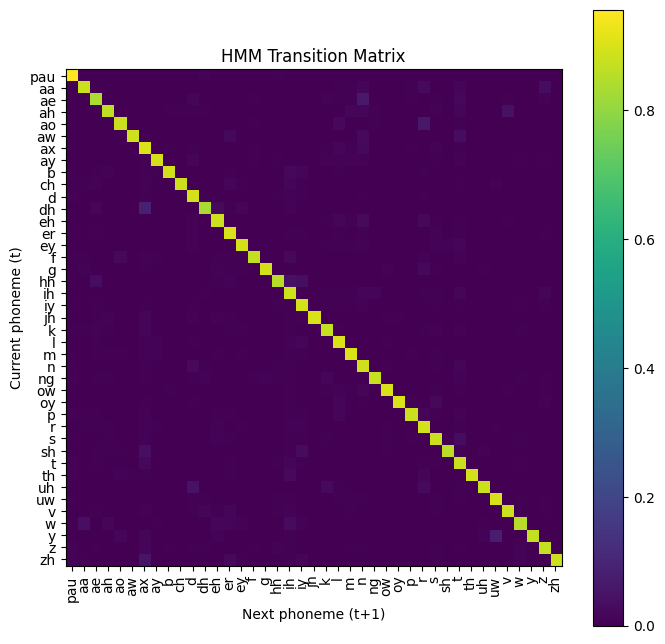

(39,)
(39, 39)


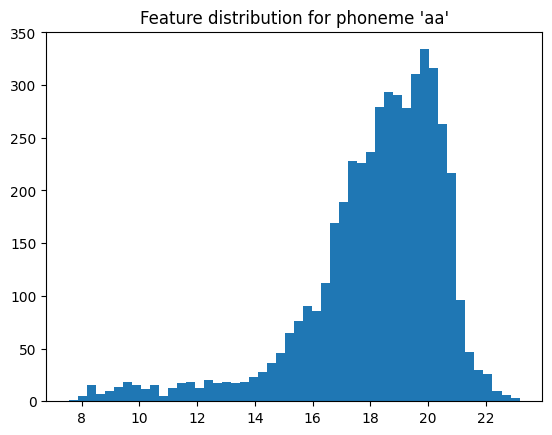

In [24]:
# Supervised parameter estimation (Task 6.2)
import matplotlib.pyplot as plt

# initial distribution
initial_dict = {}

for data in train_data:
    num = int(data[1][0])
    if num in initial_dict.keys():
        initial_dict[num] += 1
    else:
        initial_dict[num] = 1

# normalize to probabilities
pi = np.zeros(len(phoneme_set))

for k, v in initial_dict.items():
    pi[k] = v

pi = pi / np.sum(pi)

print("initital distribution:", pi)


# transition matrix
transition_dict = {}
instances_dict = {}

for data in train_data:
    labels = data[1]
    for i in range(len(labels) - 1):
        current_p = labels[i]
        next_p = labels[i + 1]
        if current_p in transition_dict.keys():
            instances_dict[current_p] += 1
            if next_p in transition_dict[current_p].keys():
                transition_dict[current_p][next_p] += 1
            else:
                transition_dict[current_p][next_p] = 1
        else:
            instances_dict[current_p] = 1
            transition_dict[current_p] = dict()
            transition_dict[current_p][next_p] = 1

# normalize each row
num_states = len(phoneme_set)
tran_matrix_A = np.zeros((num_states, num_states))

for i in transition_dict:
    for j in transition_dict[i]:
        tran_matrix_A[i, j] = transition_dict[i][j]

row_sums = tran_matrix_A.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
tran_matrix_A = tran_matrix_A / row_sums

print("Tran matrix A:", tran_matrix_A)
print("Row sums:", np.sum(tran_matrix_A, axis=1)) # should be 1 -> else normalization is wrong

# plot Transition matrix
plt.figure(figsize=(8, 8))
plt.imshow(tran_matrix_A)

plt.xticks(range(len(phoneme_set)), phoneme_set, rotation=90)
plt.yticks(range(len(phoneme_set)), phoneme_set)

plt.xlabel("Next phoneme (t+1)")
plt.ylabel("Current phoneme (t)")
plt.title("HMM Transition Matrix")
plt.colorbar()
plt.show()


# emission parameters
emission_parameters = {}

for phoneme_idx in range(len(phoneme_set)):
    # Go through training samples
    features_list = []
    for features, labels in train_data:
        # do masking once per audio file
        mask = labels == phoneme_idx
        phoneme_features = features[mask]

        if len(phoneme_features) > 0:
            features_list.append(phoneme_features)

    if len(features_list) > 0:
        all_features = np.vstack(features_list)

        mean = np.mean(all_features, axis=0)

        cov = np.cov(all_features, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-6

        emission_parameters[phoneme_idx] = {"mean": mean, "cov": cov}

# should be (39,) -> 39 dimensional
print(emission_parameters[0]["mean"].shape)

# should be (39, 39)
print(emission_parameters[0]["cov"].shape)

# should be roughly Gaussian
features = []

for X, labels in train_data:
    mask = labels == phoneme_to_idx["aa"]
    features.append(X[mask])

features = np.vstack(features)

plt.hist(features[:, 0], bins=50)
plt.title("Feature distribution for phoneme 'aa'")
plt.show()

In [25]:
# Inference Algorithms (6.3)

# Forward algorithm (filtering)

# Viterbi algorithm